version plus organiser 

In [10]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

from ipywidgets import interact, SelectMultiple

load data

In [17]:
df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

# ⚠️ garder si tu veux (mais pas optimal)
df.dropna(inplace=True)

print(df.shape)

(485151, 33)


SPLIT PUITS (FIXE)

In [18]:
wellnames = df["WELL"].dropna().unique().tolist()

np.random.seed(42)
np.random.shuffle(wellnames)

train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

#sauvegarde 
with open("split.json", "w") as f:
    json.dump({"train": train_wells, "blind": blind_wells}, f)

Train wells: 80
Blind wells: 9


FEATURES / TARGET

In [19]:
features = [
    "WHP","WHT",
    "WHP_LAG_1","WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_1","WHT_LAG_3","WHT_LAG_7",
    "GAS_LAG_1","GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_1","WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_1","COND_LAG_3","COND_LAG_7",

    "W_GAS_MEAN_3","W_GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_VOL_MEAN_3","COND_VOL_MEAN_7",

    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

DATASETS

In [20]:
# TRAIN
df_train = df[df["WELL"].isin(train_wells)].copy()

X = df_train[features]
y = df_train[targets]

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# BLIND
df_blind = df[df["WELL"].isin(blind_wells)].copy()
X_blind = df_blind[features]
y_blind = df_blind[targets]

FONCTION GÉNÉRIQUE MODEL

In [21]:
def run_model(name, model):

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)
    y_blind_pred = pipe.predict(X_blind)

    for i, target in enumerate(targets):
        print(f"{target}:")
        print(" Train R2:", r2_score(y_train.iloc[:, i], y_train_pred[:, i]))
        print(" Test  R2:", r2_score(y_test.iloc[:, i], y_test_pred[:, i]))
        print(" Blind R2:", r2_score(y_blind.iloc[:, i], y_blind_pred[:, i]))

    # 🔥 SAUVEGARDE
    os.makedirs("models", exist_ok=True)
    joblib.dump(pipe, f"models/{name}.pkl")

    return pipe, y_train_pred, y_test_pred, y_blind_pred

MODELS

In [22]:
# Linear
lr_model, y_train_lr, y_test_lr, y_blind_lr = run_model(
    "LinearRegression", LinearRegression()
)



===== LinearRegression =====
W_GAS:
 Train R2: 0.9533730973262148
 Test  R2: 0.9530420811104813
 Blind R2: 0.9420974155978383
WATER:
 Train R2: 0.973051063846428
 Test  R2: 0.9778821875906638
 Blind R2: 0.902247506346127
COND_VOL:
 Train R2: 0.963703347870225
 Test  R2: 0.9630800741600161
 Blind R2: 0.9611259795656102


In [23]:
# Random Forest
rf_model, y_train_rf, y_test_rf, y_blind_rf = run_model(
    "RandomForest",
    RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
)


===== RandomForest =====
W_GAS:
 Train R2: 0.8931830446398602
 Test  R2: 0.8892845001212044
 Blind R2: 0.8448309690392459
WATER:
 Train R2: 0.9589133594230793
 Test  R2: 0.9541065907964388
 Blind R2: 0.7630329773540915
COND_VOL:
 Train R2: 0.9727080529111045
 Test  R2: 0.9679526160970566
 Blind R2: 0.9620852106863977


In [24]:
# Decision Tree
dt_model, y_train_dt, y_test_dt, y_blind_dt = run_model(
    "DecisionTree", DecisionTreeRegressor(max_depth=10)
)


===== DecisionTree =====
W_GAS:
 Train R2: 0.8904191948668465
 Test  R2: 0.8853613206611795
 Blind R2: 0.8302292853166893
WATER:
 Train R2: 0.9488920252067038
 Test  R2: 0.9399113139885888
 Blind R2: 0.6023955454631689
COND_VOL:
 Train R2: 0.9714837977520256
 Test  R2: 0.9647291234196107
 Blind R2: 0.9582958760002555


ANN (STRUCTURÉ)

In [25]:
def run_ann():
    os.makedirs("models", exist_ok=True)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_blind_s = scaler.transform(X_blind)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(3)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train_s, y_train.values, epochs=50, batch_size=512, verbose=0)

    y_train_pred = model.predict(X_train_s)
    y_test_pred  = model.predict(X_test_s)
    y_blind_pred = model.predict(X_blind_s)
    model.save("models/ANN.h5")
    joblib.dump(scaler, "models/ANN_scaler.pkl")
    return model, y_train_pred, y_test_pred, y_blind_pred


ann_model, y_train_ann, y_test_ann, y_blind_ann = run_ann()

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11057/11057 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


COMPARAISON

In [26]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])

        print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")


evaluate_model("LR", y_test, y_test_lr)
evaluate_model("DT", y_test, y_test_dt)
evaluate_model("RF", y_test, y_test_rf)
evaluate_model("ANN", y_test, y_test_ann)


===== LR =====
W_GAS -> MAE: 0.0141 | R2: 0.9530
WATER -> MAE: 0.1488 | R2: 0.9779
COND_VOL -> MAE: 2.4140 | R2: 0.9631

===== DT =====
W_GAS -> MAE: 0.0438 | R2: 0.8854
WATER -> MAE: 0.7502 | R2: 0.9399
COND_VOL -> MAE: 2.4714 | R2: 0.9647

===== RF =====
W_GAS -> MAE: 0.0434 | R2: 0.8893
WATER -> MAE: 0.6729 | R2: 0.9541
COND_VOL -> MAE: 2.2928 | R2: 0.9680

===== ANN =====
W_GAS -> MAE: 0.0240 | R2: 0.9508
WATER -> MAE: 0.2111 | R2: 0.9797
COND_VOL -> MAE: 2.0463 | R2: 0.9723


SAVE RESULTS

In [27]:
os.makedirs("results", exist_ok=True)

def save_pred(name, y_pred):
    df_save = df_blind.loc[X_blind.index].copy()

    df_save[f"GAS_{name}"]   = y_pred[:,0]
    df_save[f"WATER_{name}"] = y_pred[:,1]
    df_save[f"COND_{name}"]  = y_pred[:,2]

    df_save.to_csv(f"results/pred_{name}.csv", index=False)


save_pred("LR", y_blind_lr)
save_pred("DT", y_blind_dt)
save_pred("RF", y_blind_rf)
save_pred("ANN", y_blind_ann)

INTERACTIVE PLOT

In [28]:
df_plot = df_blind.loc[X_blind.index].copy()
df_plot["DATE"] = pd.to_datetime(df_plot["DATE"])

df_plot["LR"] = y_blind_lr[:,0]
df_plot["RF"] = y_blind_rf[:,0]
df_plot["ANN"] = y_blind_ann[:,0]
df_plot["DT"] = y_blind_dt[:,0]

def plot_wells(model="LR"):

    wells = df_plot["WELL"].unique()

    fig, ax = plt.subplots(3,2, figsize=(20,20))

    row = [0,0,1,1,2,2]
    col = [0,1,0,1,0,1]

    for i, well in enumerate(wells[:6]):

        dfp = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfp["DATE"], dfp["W_GAS"], label="Real")
        ax[row[i], col[i]].plot(dfp["DATE"], dfp[model], color="green", label=model)

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].legend()

    plt.tight_layout()
    plt.show()


interact(plot_wells, model=["LR","RF","ANN","DT"])

interactive(children=(Dropdown(description='model', options=('LR', 'RF', 'ANN', 'DT'), value='LR'), Output()),…

<function __main__.plot_wells(model='LR')>

comparison table

In [29]:
def build_blind_comparison():

    results = []

    models = {
        "LR": y_blind_lr,
        "DT": y_blind_dt,
        "RF": y_blind_rf,
        "ANN": y_blind_ann
    }

    for model_name, y_pred in models.items():

        for i, target in enumerate(targets):

            mae = mean_absolute_error(y_blind.iloc[:, i], y_pred[:, i])
            r2  = r2_score(y_blind.iloc[:, i], y_pred[:, i])

            results.append({
                "Model": model_name,
                "Target": target,
                "MAE": mae,
                "R2": r2
            })

    return pd.DataFrame(results)

In [30]:
df_blind_compare = build_blind_comparison()
print(df_blind_compare)

   Model    Target       MAE        R2
0     LR     W_GAS  0.011628  0.942097
1     LR     WATER  0.318184  0.902248
2     LR  COND_VOL  1.946492  0.961126
3     DT     W_GAS  0.039102  0.830229
4     DT     WATER  1.257740  0.602396
5     DT  COND_VOL  2.207820  0.958296
6     RF     W_GAS  0.037563  0.844831
7     RF     WATER  1.029248  0.763033
8     RF  COND_VOL  2.007661  0.962085
9    ANN     W_GAS  0.022046  0.923491
10   ANN     WATER  0.370806  0.910672
11   ANN  COND_VOL  1.737115  0.967812


In [31]:
pivot_r2 = df_blind_compare.pivot(index="Model", columns="Target", values="R2")
print(pivot_r2)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.967812  0.910672  0.923491
DT      0.958296  0.602396  0.830229
LR      0.961126  0.902248  0.942097
RF      0.962085  0.763033  0.844831


selection of the best model

In [32]:
df_global = df_blind_compare.groupby("Model")["R2"].mean().reset_index()
df_global = df_global.sort_values("R2", ascending=False)

print(df_global)

best_model = df_global.iloc[0]["Model"]
print("Best model:", best_model)

  Model        R2
2    LR  0.935157
0   ANN  0.933992
3    RF  0.856650
1    DT  0.796974
Best model: LR


pearson correlation


In [33]:
def pearson_model(name, y_true, y_pred):

    results = []

    for i, target in enumerate(targets):

        corr = np.corrcoef(y_true.iloc[:, i], y_pred[:, i])[0,1]

        results.append({
            "Model": name,
            "Target": target,
            "Pearson": corr
        })

    return results

In [34]:
pearson_results = []

pearson_results += pearson_model("LR", y_blind, y_blind_lr)
pearson_results += pearson_model("DT", y_blind, y_blind_dt)
pearson_results += pearson_model("RF", y_blind, y_blind_rf)
pearson_results += pearson_model("ANN", y_blind, y_blind_ann)

df_pearson = pd.DataFrame(pearson_results)

#print(df_pearson)

In [35]:
pivot_pearson = df_pearson.pivot(index="Model", columns="Target", values="Pearson")
print(pivot_pearson)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.984191  0.954893  0.963625
DT      0.978934  0.797437  0.918391
LR      0.980385  0.950105  0.970645
RF      0.980878  0.873862  0.924879


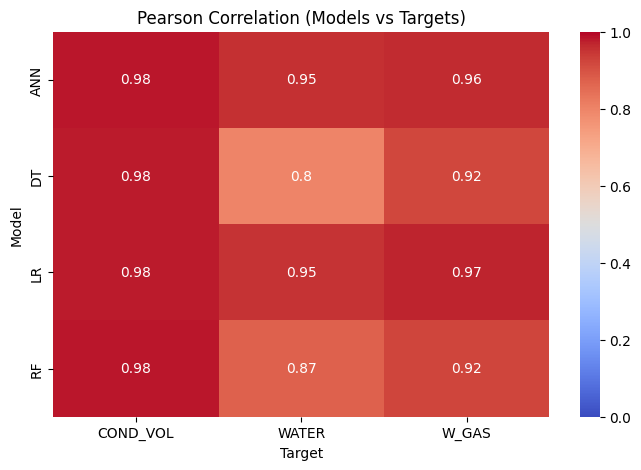

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(pivot_pearson, annot=True, cmap="coolwarm", vmin=0, vmax=1)

plt.title("Pearson Correlation (Models vs Targets)")
plt.show()

In [37]:
# Simuler panne (on cache les vraies valeurs)
df_virtual = df.copy()

df_virtual["W_GAS_real"] = df_virtual["W_GAS"]
df_virtual["WATER_real"] = df_virtual["WATER"]
df_virtual["COND_real"] = df_virtual["COND_VOL"]

# Supprimer mesure (comme si capteur HS)
df_virtual["W_GAS"] = np.nan
df_virtual["WATER"] = np.nan
df_virtual["COND_VOL"] = np.nan

In [38]:
os.makedirs("models", exist_ok=True)

# 🔥 sauvegarde config
with open("models/config.json", "w") as f:
    json.dump({
        "features": features,
        "targets": targets
    }, f)

print("✅ Config sauvegardée")

✅ Config sauvegardée
